# The convolution Sum

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import style 

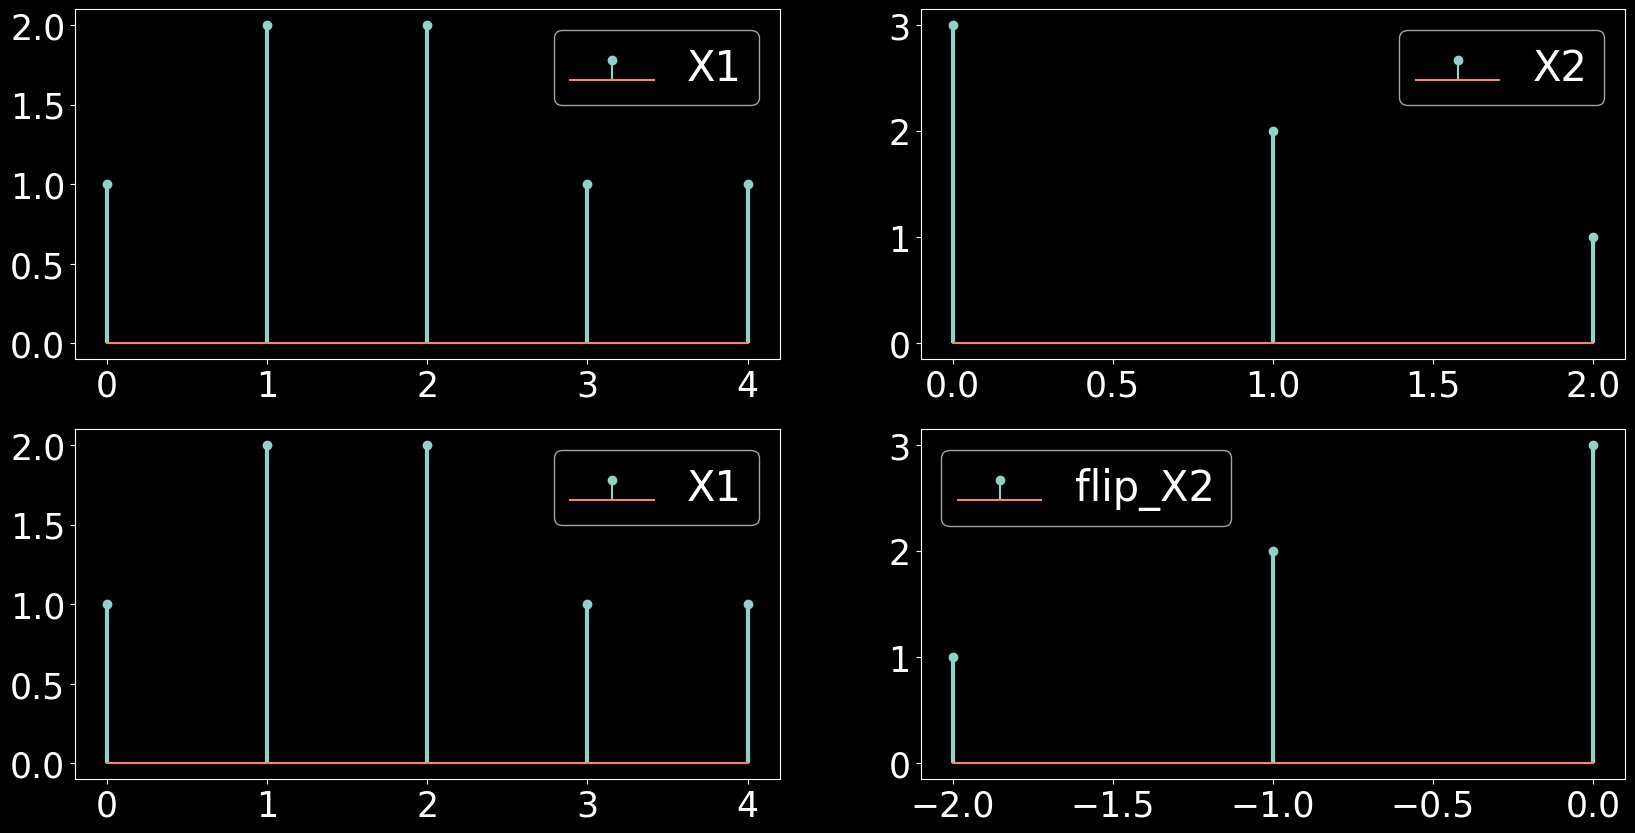

In [3]:
# Generating and Plotting X1

x1 = np.array([1,2,2,1,1])
n1 = np.array([0,1,2,3,4])
plt.figure(figsize= (20,10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 25 
plt.rcParams['ytick.labelsize'] = 25 
plt.subplot(2,2,1)
markerline, stemlines, baseline = plt.stem(n1,x1, label = 'X1')
plt.setp(stemlines, 'linewidth', 3)
plt.legend(fontsize = 30)


# Generating and Plotting X2

x2 = np.array([3, 2, 1])
n2 = np.array([0, 1, 2])
plt.subplot(2,2,2)
markerline, stemlines, baseline = plt.stem(n2,x2, label = 'X2')
plt.setp(stemlines, 'linewidth', 3)
plt.legend(fontsize = 30)

# Plotting X1 at position 3
plt.subplot(2,2,3)
markerline, stemlines, baseline = plt.stem(n1,x1, label = 'X1')
plt.legend(fontsize = 30)
plt.setp(stemlines, 'linewidth', 3)

# FLipping of x2 and plotting

f_x2 = x2[::-1]
n3 = np.array([-2,-1,0])
plt.subplot(2,2,4)
markerline, stemlines, baseline = plt.stem(n3,f_x2, label = 'flip_X2')
plt.setp(stemlines, 'linewidth', 3)
plt.legend(fontsize = 30)
plt.show()


# Calculating convolution for mode = 'full'

In [5]:
nx1 = len(x1)
nx2 = len(x2)
nconv = nx1 + nx2 - 1

print(nx1)
print(nx2)
print(nconv)

5
3
7


In [6]:
# Expanding x1 by zero padding

half_nx2 = int(np.round(nx2/2))

data_4_conv = np.concatenate((np.zeros(half_nx2), x1 , np.zeros(half_nx2)), axis= 0) # zero padding on both sides of x1

print(half_nx2)
print(np.zeros(half_nx2))
print(data_4_conv)

2
[0. 0.]
[0. 0. 1. 2. 2. 1. 1. 0. 0.]


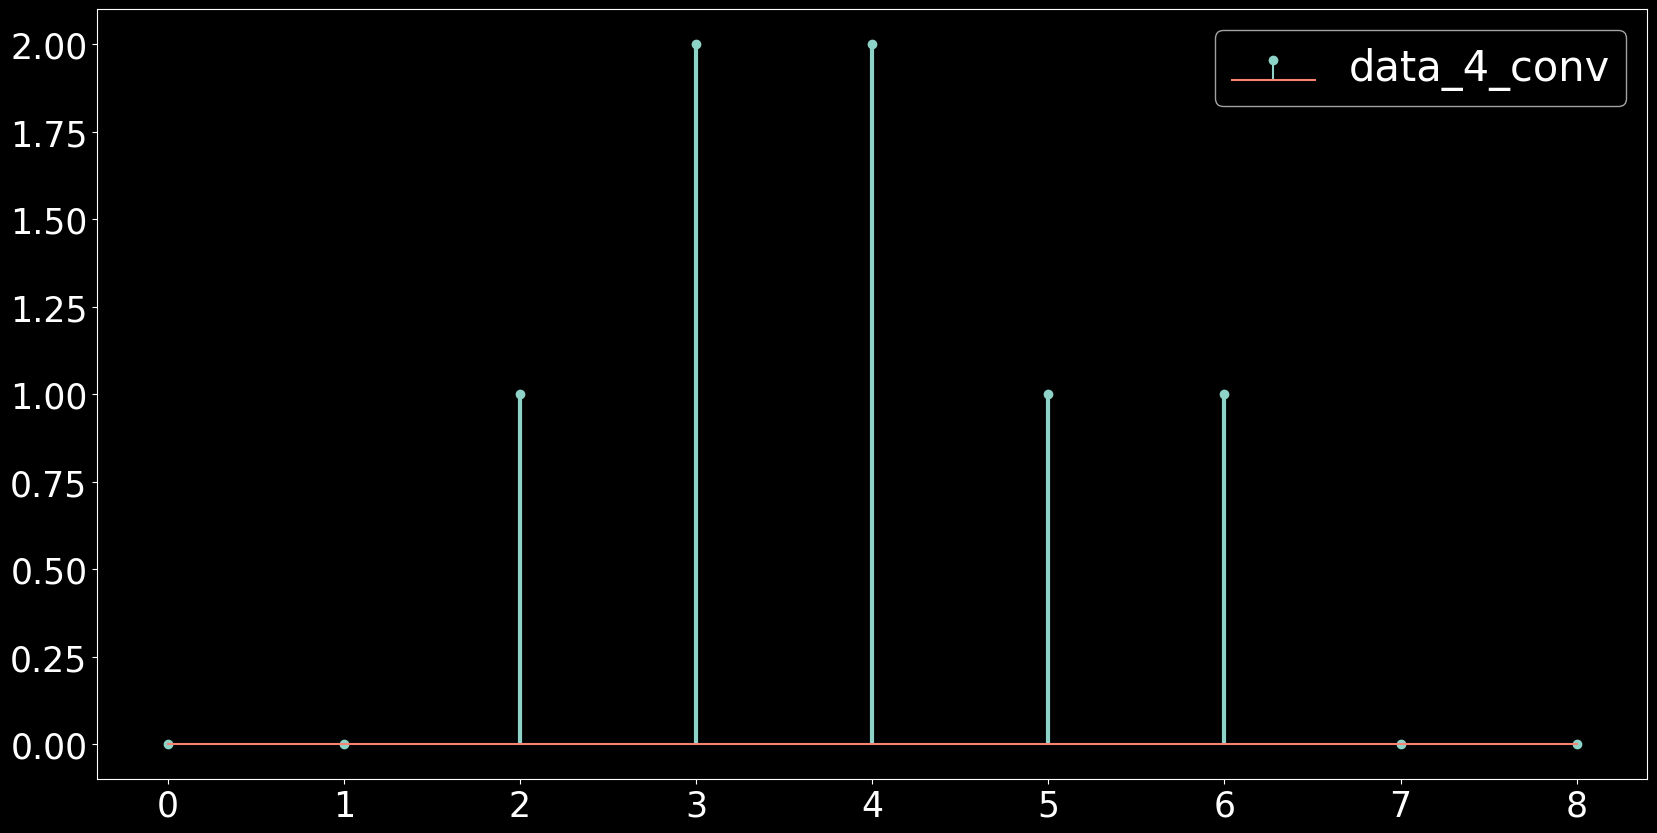

In [7]:
plt.figure(figsize= (20,10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 25 
plt.rcParams['ytick.labelsize'] = 25 
markerline, stemlines, baseline = plt.stem(data_4_conv, label = 'data_4_conv')
plt.setp(stemlines, 'linewidth', 3)
plt.legend(fontsize = 30)
plt.show()

# Convolution by for loops

In [8]:
convres = np.zeros(nconv) # nconv = 7
for i in range(0,nconv): 
	convres[i] = np.sum(f_x2 * data_4_conv[i:i+nx2])

In [9]:
convres

array([ 3.,  8., 11.,  9.,  7.,  3.,  1.])

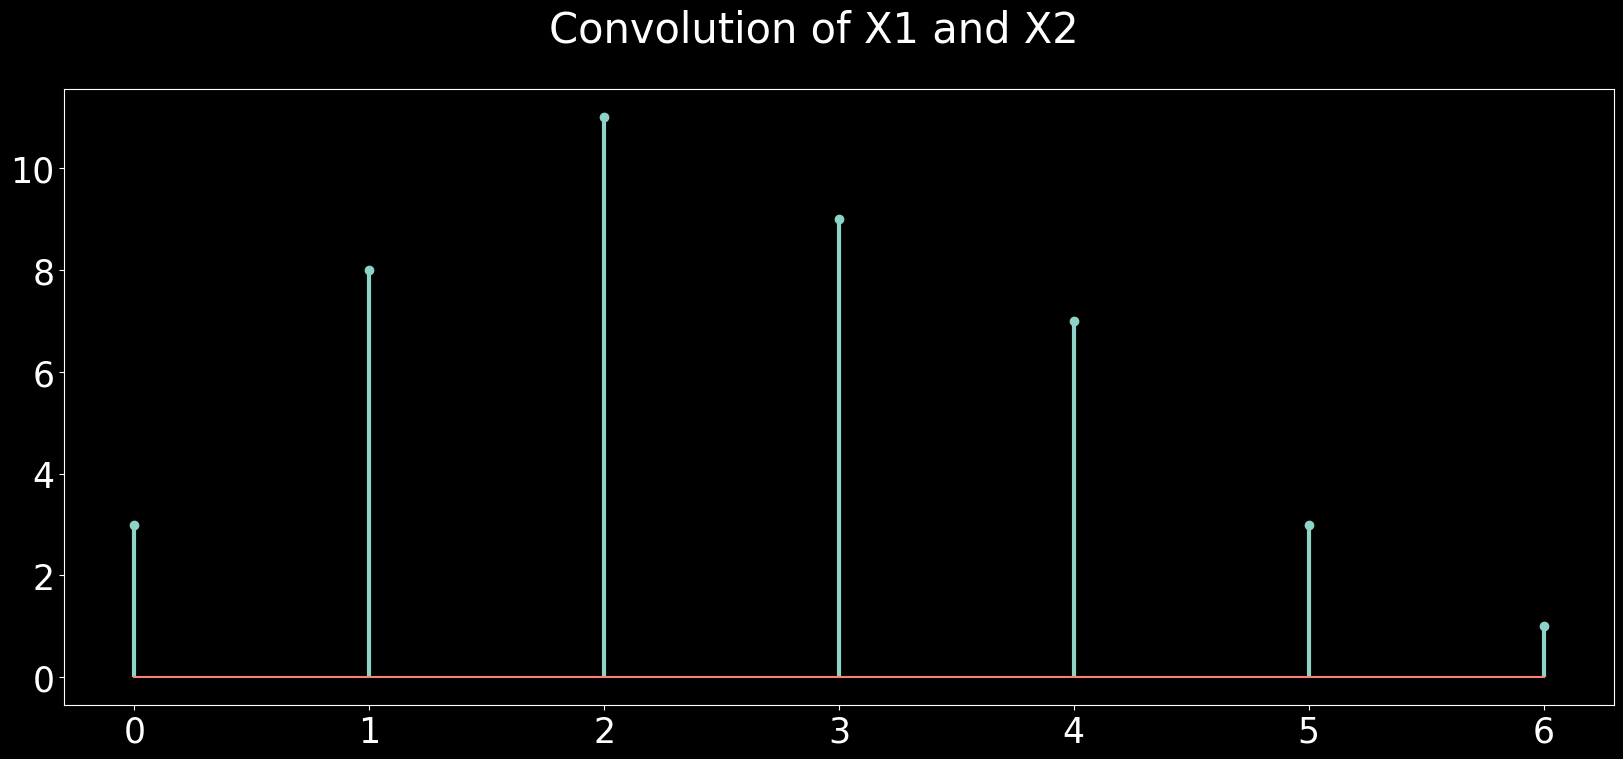

In [10]:
plt.figure(figsize= (20,8))
plt.suptitle('Convolution of X1 and X2', fontsize = 30)
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 25 
plt.rcParams['ytick.labelsize'] = 25 
markerline, stemlines, baseline = plt.stem(convres)
plt.setp(stemlines, 'linewidth', 3)
plt.show()

# Convolution by np.convolve using mode = "full"

In [11]:
np.convolve(x1,x2, mode = 'full') # rather than doing the extra steps by using for loops, you can just use numpy to find the convolution

array([ 3,  8, 11,  9,  7,  3,  1])

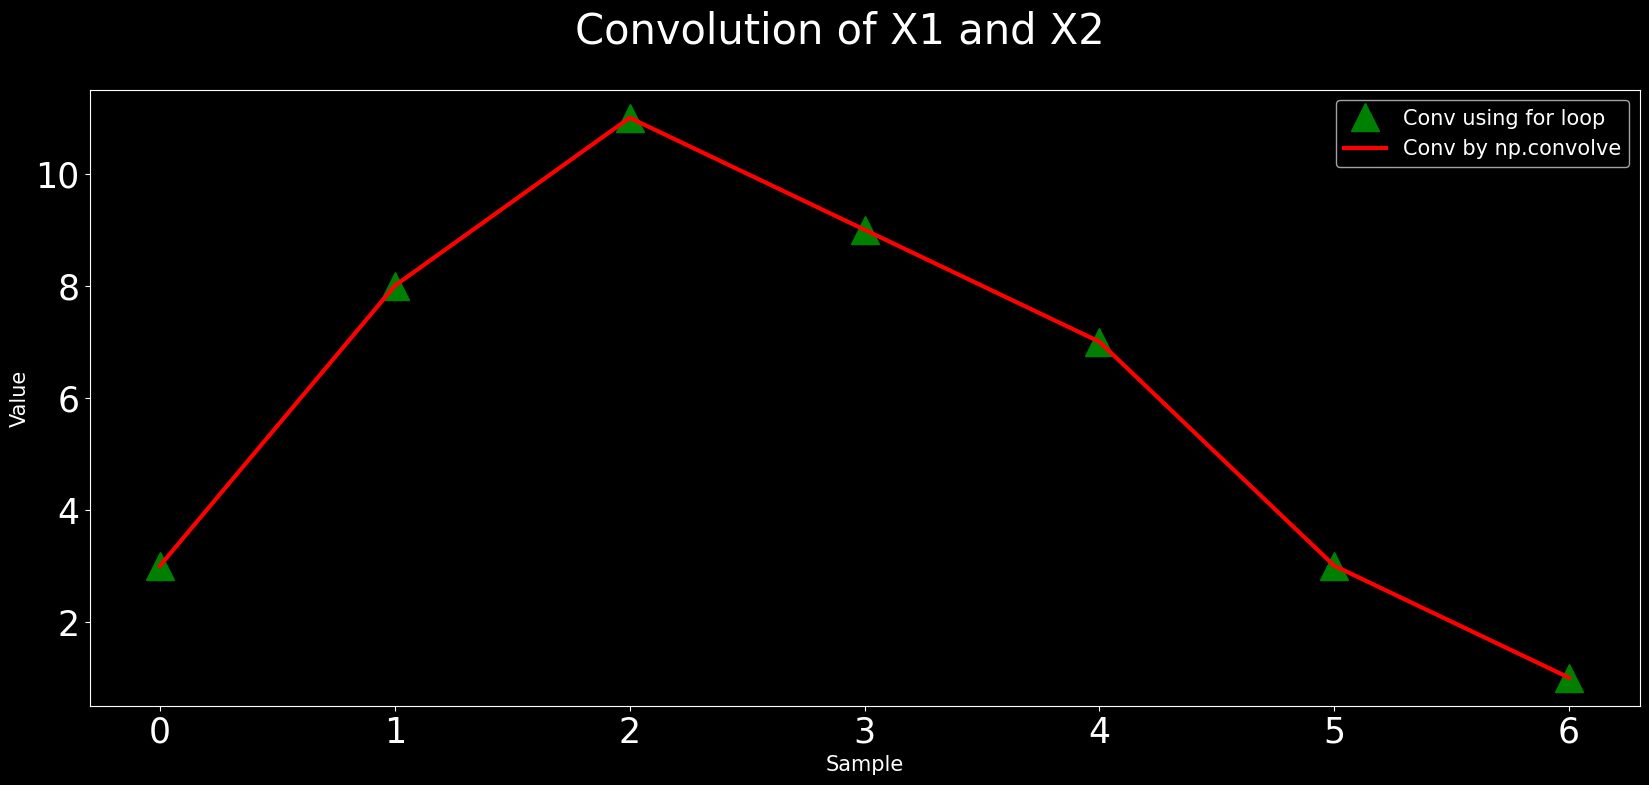

In [13]:
plt.figure(figsize= (20,8))
plt.suptitle('Convolution of X1 and X2', fontsize = 30)
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 25 
plt.rcParams['ytick.labelsize'] = 25 
plt.plot(convres,'g^', markersize = 20, label = 'Conv using for loop')
plt.plot(np.convolve(x1,x2, mode='full'), 'r-', linewidth = 3, label = 'Conv by np.convolve')
plt.xlabel('Sample', fontsize = 15)
plt.ylabel('Value', fontsize = 15)
plt.legend(fontsize = 15)
plt.show()